In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [3]:
df=pd.read_csv("flights_sample_2m.csv")

In [4]:
print(df.sample(5))

            FL_DATE                 AIRLINE                 AIRLINE_DOT  \
1225087  2023-06-25  Southwest Airlines Co.  Southwest Airlines Co.: WN   
151078   2019-01-07   SkyWest Airlines Inc.   SkyWest Airlines Inc.: OO   
1160506  2022-06-20   SkyWest Airlines Inc.   SkyWest Airlines Inc.: OO   
1734394  2020-03-10  American Airlines Inc.  American Airlines Inc.: AA   
606945   2020-02-16   SkyWest Airlines Inc.   SkyWest Airlines Inc.: OO   

        AIRLINE_CODE  DOT_CODE  FL_NUMBER ORIGIN         ORIGIN_CITY DEST  \
1225087           WN     19393        793    SAN       San Diego, CA  DEN   
151078            OO     20304       3430    SLC  Salt Lake City, UT  PDX   
1160506           OO     20304       5080    DEC         Decatur, IL  ORD   
1734394           AA     19805       1729    ORD         Chicago, IL  MIA   
606945            OO     20304       3099    ORD         Chicago, IL  SLC   

                  DEST_CITY  ...  DIVERTED  CRS_ELAPSED_TIME  ELAPSED_TIME  \
1225087 

In [5]:
print(df.shape)

(2000000, 32)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [7]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,2.000000e+06,2.000000e+06,2.000000e+06,1.948570e+06,1.948551e+06,1.947719e+06,1.947719e+06,1.946909e+06,1.946909e+06,2.000000e+06,...,2.000000e+06,1.999983e+06,1.942769e+06,1.942769e+06,2.000000e+06,356220.000000,356220.000000,356220.000000,356220.000000,356220.000000
mean,1.997606e+04,2.509791e+03,1.327164e+03,1.329807e+03,1.017531e+01,1.665830e+01,1.352373e+03,1.462219e+03,7.666778e+00,1.490406e+03,...,2.354500e-03,1.423172e+02,1.366519e+02,1.123382e+02,8.097667e+02,24.932850,3.966540,13.125599,0.138353,25.568724
std,3.772420e+02,1.746913e+03,4.857417e+02,4.991379e+02,4.962964e+01,9.216145e+00,5.007146e+02,5.273262e+02,6.256421e+00,5.116217e+02,...,4.846604e-02,7.164440e+01,7.175737e+01,6.983312e+01,5.886667e+02,73.244243,31.813991,32.563686,2.885851,56.309120
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,-7.700000e+01,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.048000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.320000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.780000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.335000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.790000e+03,1.730000e+03,1.738000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,8.816000e+03,2.359000e+03,2.400000e+03,3.221000e+03,2.560000e+02,2.400000e+03,2.400000e+03,2.810000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.950000e+02,7.270000e+02,5.095000e+03,3221.000000,1468.000000,1711.000000,395.000000,2069.000000


In [8]:
print(df.columns)

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')


In [9]:
print(df.nunique)

<bound method DataFrame.nunique of             FL_DATE                 AIRLINE                 AIRLINE_DOT  \
0        2020-03-17   United Air Lines Inc.   United Air Lines Inc.: UA   
1        2019-11-03  Southwest Airlines Co.  Southwest Airlines Co.: WN   
2        2020-04-02  Southwest Airlines Co.  Southwest Airlines Co.: WN   
3        2022-09-03               Envoy Air               Envoy Air: MQ   
4        2021-05-04    Delta Air Lines Inc.    Delta Air Lines Inc.: DL   
...             ...                     ...                         ...   
1999995  2022-10-30    Alaska Airlines Inc.    Alaska Airlines Inc.: AS   
1999996  2021-05-03  Southwest Airlines Co.  Southwest Airlines Co.: WN   
1999997  2023-08-25  Southwest Airlines Co.  Southwest Airlines Co.: WN   
1999998  2022-04-17       Endeavor Air Inc.       Endeavor Air Inc.: 9E   
1999999  2019-02-12   SkyWest Airlines Inc.   SkyWest Airlines Inc.: OO   

        AIRLINE_CODE  DOT_CODE  FL_NUMBER ORIGIN                

In [10]:
print(df.describe(include=['O']).T)

                     count unique                         top    freq
FL_DATE            2000000   1704                  2019-12-01    1594
AIRLINE            2000000     18      Southwest Airlines Co.  384493
AIRLINE_DOT        2000000     18  Southwest Airlines Co.: WN  384493
AIRLINE_CODE       2000000     18                          WN  384493
ORIGIN             2000000    380                         ATL  102727
ORIGIN_CITY        2000000    373                 Chicago, IL  105546
DEST               2000000    380                         ATL  102396
DEST_CITY          2000000    373                 Chicago, IL  105231
CANCELLATION_CODE    52522      4                           B   19022


In [11]:
df['IS_LATE'] = np.where(df['ARR_DELAY'] > 15, 1, 0)

In [12]:
print(df['IS_LATE'].value_counts(dropna=False))

IS_LATE
0    1656125
1     343875
Name: count, dtype: int64


In [13]:
print(df['IS_LATE'].value_counts(normalize=True) * 100)

IS_LATE
0    82.80625
1    17.19375
Name: proportion, dtype: float64


In [14]:
print(df['CANCELLED'].value_counts(normalize=True) * 100)

CANCELLED
0.0    97.3739
1.0     2.6261
Name: proportion, dtype: float64


In [15]:
df.isnull().sum()
# df.isnull().sum() / len(df)) * 100

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     51430
DEP_DELAY                    51449
TAXI_OUT                     52281
WHEELS_OFF                   52281
WHEELS_ON                    53091
TAXI_IN                      53091
CRS_ARR_TIME                     0
ARR_TIME                     53091
ARR_DELAY                    57231
CANCELLED                        0
CANCELLATION_CODE          1947478
DIVERTED                         0
CRS_ELAPSED_TIME                17
ELAPSED_TIME                 57231
AIR_TIME                     57231
DISTANCE                         0
DELAY_DUE_CARRIER          1643780
DELAY_DUE_WEATHER   

In [16]:
delay_cols = [
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'
]
df[delay_cols] = df[delay_cols].fillna(0)

df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('None')

df = df.dropna(subset=['CRS_ELAPSED_TIME'])

df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

print(df_clean.isnull().sum())

FL_DATE                    0
AIRLINE                    0
AIRLINE_DOT                0
AIRLINE_CODE               0
DOT_CODE                   0
FL_NUMBER                  0
ORIGIN                     0
ORIGIN_CITY                0
DEST                       0
DEST_CITY                  0
CRS_DEP_TIME               0
DEP_TIME                   0
DEP_DELAY                  0
TAXI_OUT                   0
WHEELS_OFF                 0
WHEELS_ON                  0
TAXI_IN                    0
CRS_ARR_TIME               0
ARR_TIME                   0
ARR_DELAY                  0
CANCELLED                  0
CANCELLATION_CODE          0
DIVERTED                   0
CRS_ELAPSED_TIME           0
ELAPSED_TIME               0
AIR_TIME                   0
DISTANCE                   0
DELAY_DUE_CARRIER          0
DELAY_DUE_WEATHER          0
DELAY_DUE_NAS              0
DELAY_DUE_SECURITY         0
DELAY_DUE_LATE_AIRCRAFT    0
IS_LATE                    0
dtype: int64


In [17]:
dup_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {dup_count}")

Total Duplicate Rows: 0


In [18]:
print("Null count in df_clean:")
print(df_clean[['ARR_DELAY', 'DEP_DELAY', 'AIR_TIME', 'CRS_ELAPSED_TIME']].isnull().sum())
print(f"\nRemaining clean rows: {len(df_clean):,}")

Null count in df_clean:
ARR_DELAY           0
DEP_DELAY           0
AIR_TIME            0
CRS_ELAPSED_TIME    0
dtype: int64

Remaining clean rows: 1,942,769


In [19]:
q1 = df_clean['ARR_DELAY'].quantile(0.25)
q3 = df_clean['ARR_DELAY'].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers_iqr = df_clean[(df_clean['ARR_DELAY'] < lower_limit) | (df_clean['ARR_DELAY'] > upper_limit)]

print("--- IQR Outlier Summary ---")
print(f"Q1 (25%): {q1:.1f} min | Q3 (75%): {q3:.1f} min | IQR: {iqr:.1f}")
print(f"Lower Bound: {lower_limit:.1f} min | Upper Bound: {upper_limit:.1f} min")
print(f"Outliers Count: {len(outliers_iqr):,} ({len(outliers_iqr) / len(df_clean) * 100:.2f}%)")

--- IQR Outlier Summary ---
Q1 (25%): -16.0 min | Q3 (75%): 7.0 min | IQR: 23.0
Lower Bound: -50.5 min | Upper Bound: 41.5 min
Outliers Count: 172,297 (8.87%)


In [20]:
# Set visualization theme
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Feature Engineering from Date
df_clean['FL_DATE'] = pd.to_datetime(df_clean['FL_DATE'])
df_clean['MONTH'] = df_clean['FL_DATE'].dt.month
df_clean['DAY_OF_WEEK'] = df_clean['FL_DATE'].dt.dayofweek

# 2. Target Definition (Delay > 15 minutes)
df_clean['IS_DELAYED'] = (df_clean['ARR_DELAY'] > 15).astype(int)

# 3. Define Column Categories
continuous_num_cols = [
    'ARR_DELAY', 'DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 
    'AIR_TIME', 'ELAPSED_TIME', 'DISTANCE'
]
scheduled_time_cols = ['CRS_DEP_TIME', 'CRS_ARR_TIME']
all_num_cols = continuous_num_cols + scheduled_time_cols
target_col = 'IS_DELAYED'

EDA

Univariate Analysis


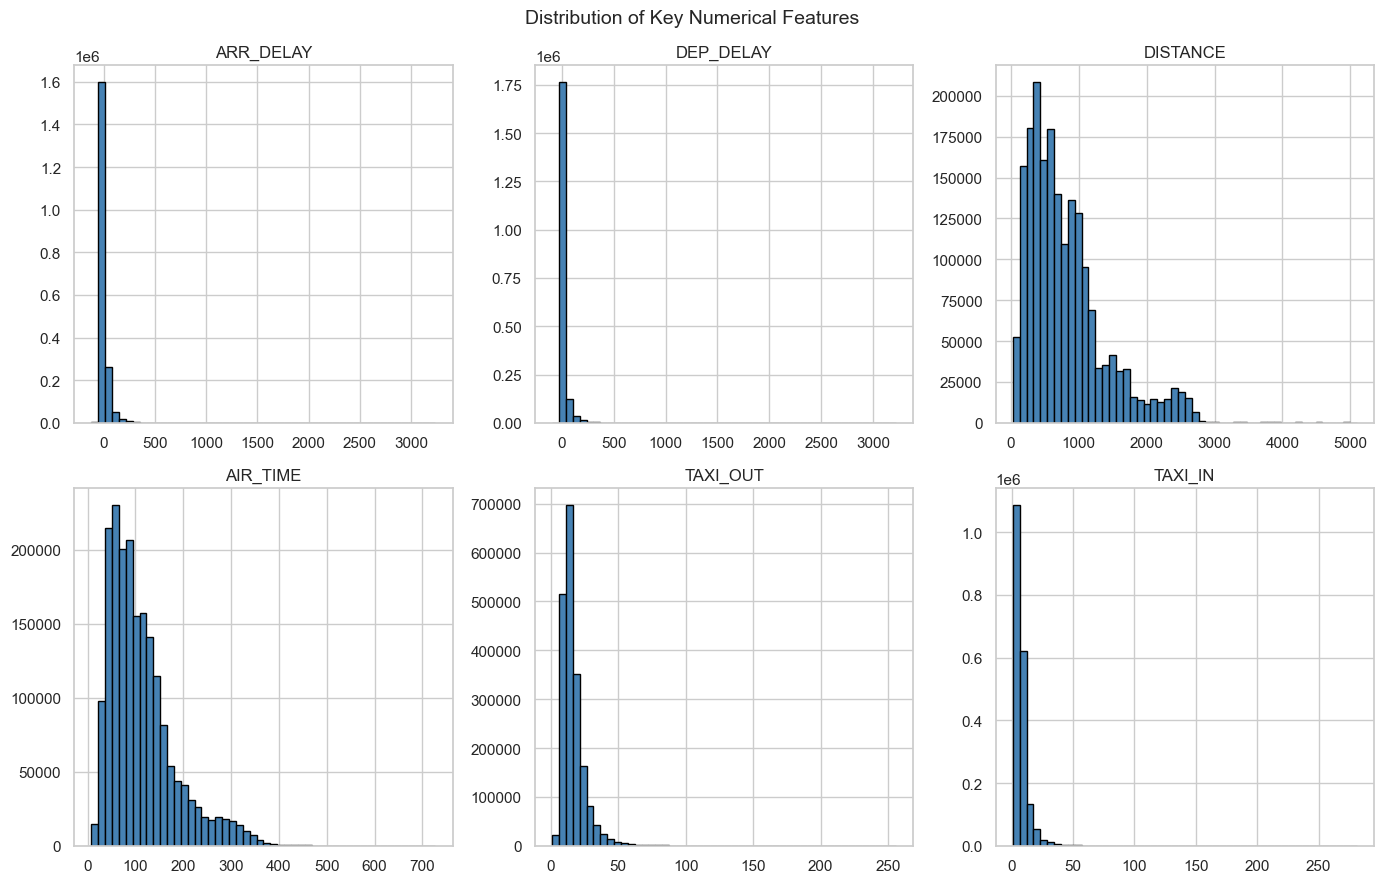

In [21]:
# Define primary continuous numerical features
num_cols = ['ARR_DELAY', 'DEP_DELAY', 'DISTANCE', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']

# Plot histograms for all selected numerical features
df_clean[num_cols].hist(
    bins=50, 
    figsize=(14, 9), 
    color='steelblue', 
    edgecolor='black', 
    layout=(2, 3)
)
plt.suptitle('Distribution of Key Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

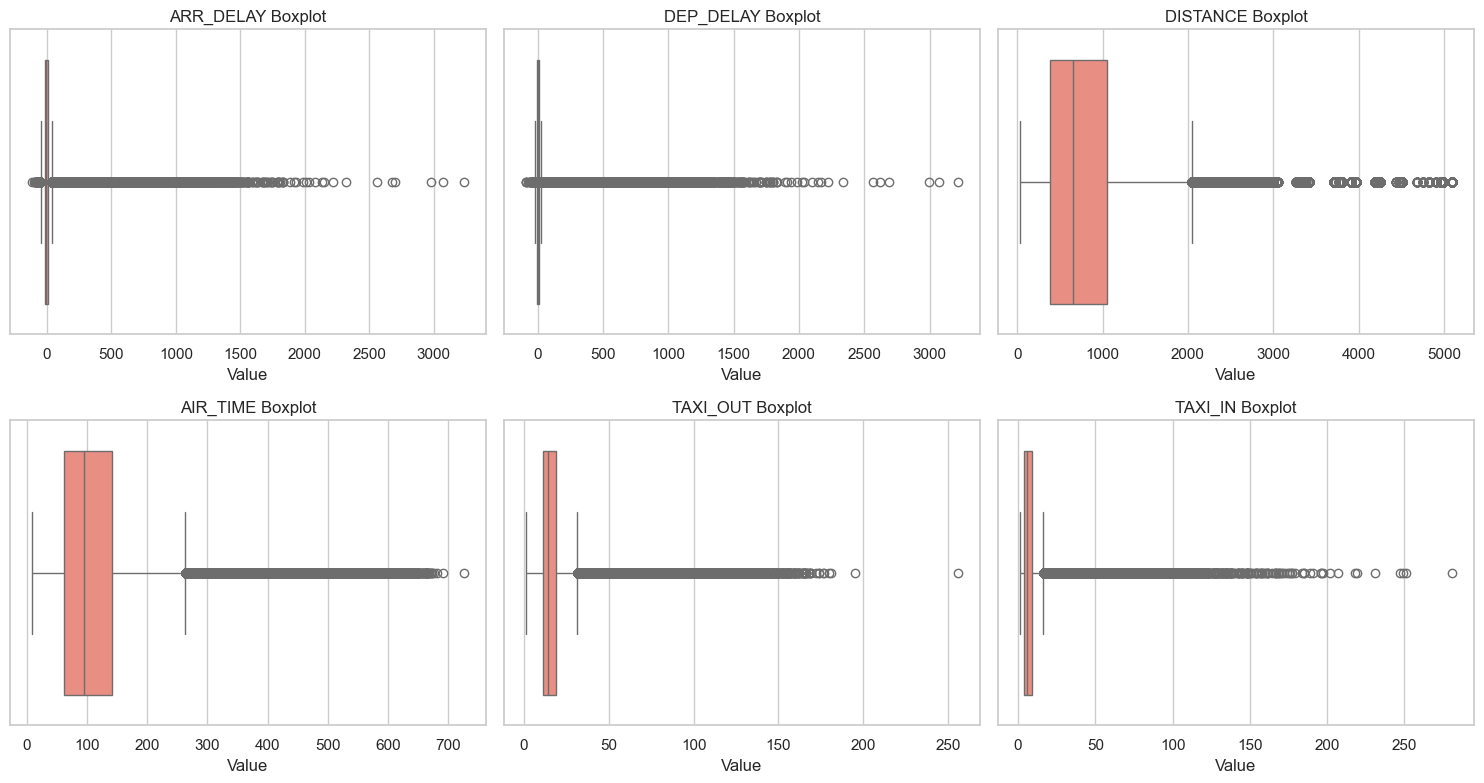

In [22]:
# Create subplots for boxplots (2 rows x 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

# Plot horizontal boxplot for each feature
for i, col in enumerate(num_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_xlabel('Value')

plt.tight_layout()
plt.show()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_7096\629852971.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['On-Time / Early (0)', 'Delayed (1)'])


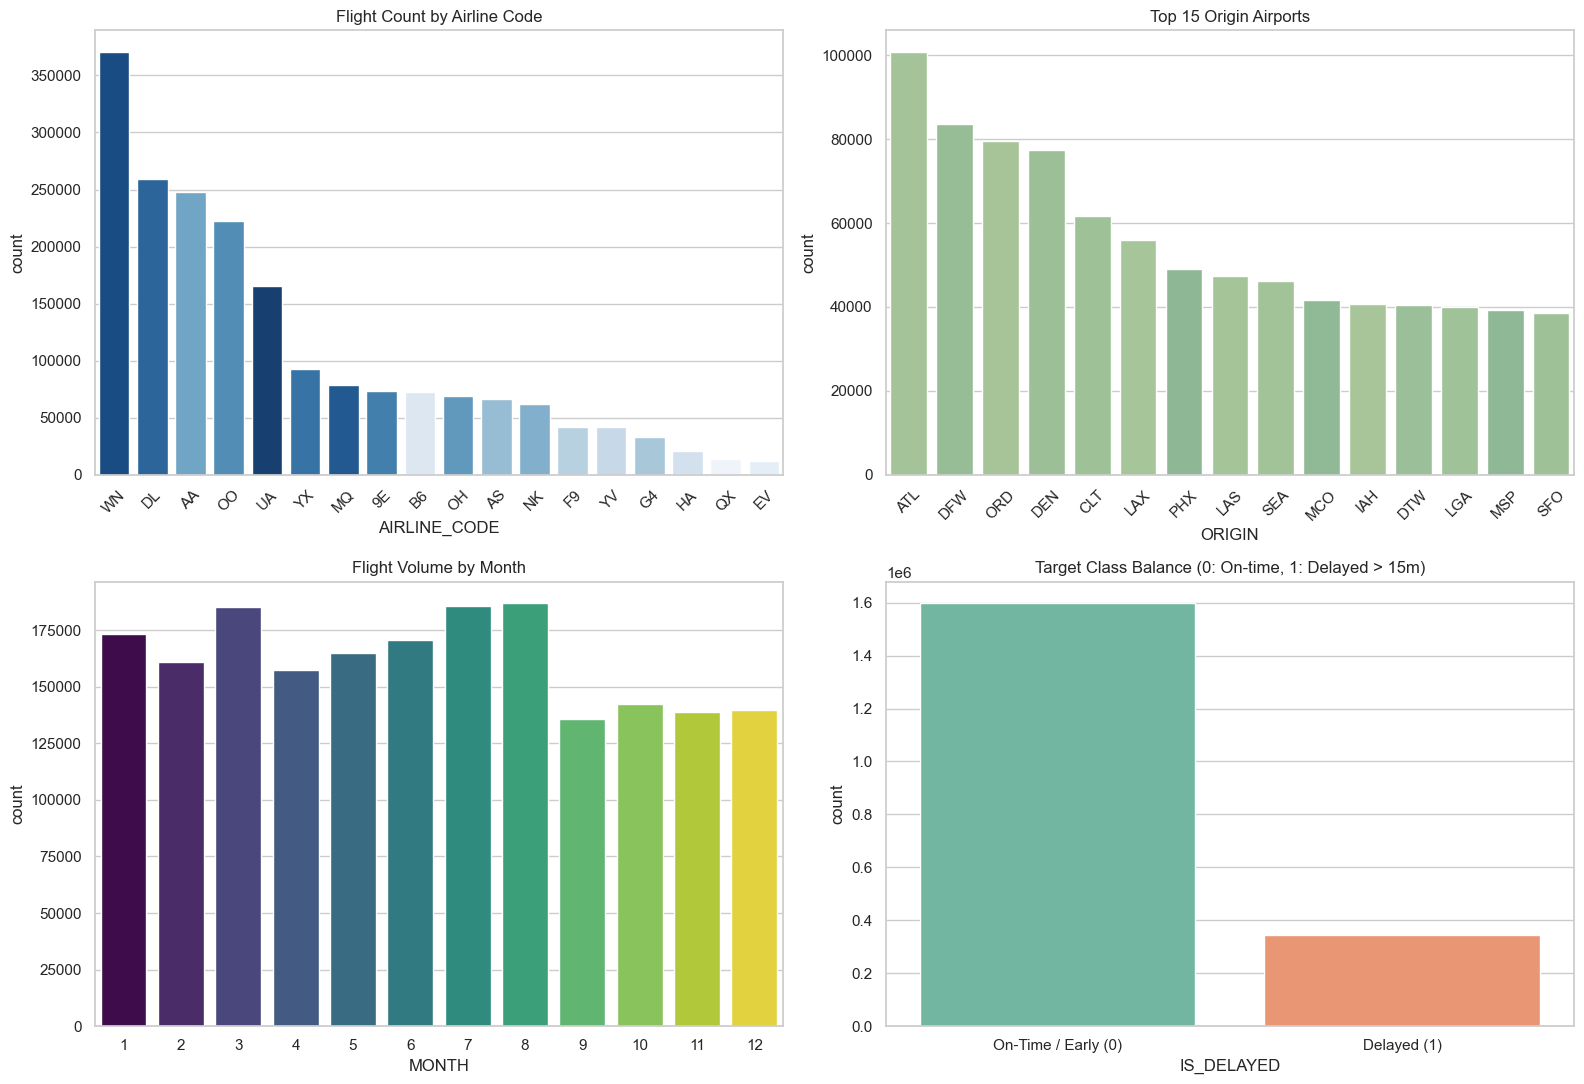

In [23]:
# Create a 2x2 grid for categorical count plots
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Top Airlines by flight count
top_airlines = df_clean['AIRLINE_CODE'].value_counts().index
sns.countplot(
    data=df_clean, 
    x='AIRLINE_CODE', 
    order=top_airlines, 
    hue='AIRLINE_CODE', 
    ax=axes[0, 0], 
    palette='Blues_r', 
    legend=False
)
axes[0, 0].set_title('Flight Count by Airline Code')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Top 15 Origin Airports
top_origins = df_clean['ORIGIN'].value_counts().head(15).index
sns.countplot(
    data=df_clean, 
    x='ORIGIN', 
    order=top_origins, 
    hue='ORIGIN', 
    ax=axes[0, 1], 
    palette='crest', 
    legend=False
)
axes[0, 1].set_title('Top 15 Origin Airports')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Flight Volume by Month
sns.countplot(
    data=df_clean, 
    x='MONTH', 
    hue='MONTH', 
    ax=axes[1, 0], 
    palette='viridis', 
    legend=False
)
axes[1, 0].set_title('Flight Volume by Month')

# 4. Target Class Balance (IS_DELAYED)
sns.countplot(
    data=df_clean, 
    x='IS_DELAYED', 
    hue='IS_DELAYED', 
    ax=axes[1, 1], 
    palette='Set2', 
    legend=False
)
axes[1, 1].set_title('Target Class Balance (0: On-time, 1: Delayed > 15m)')
axes[1, 1].set_xticklabels(['On-Time / Early (0)', 'Delayed (1)'])

plt.tight_layout()
plt.show()

skewed detection

In [24]:
# Define numerical columns to inspect
continuous_num_cols = [
    'ARR_DELAY', 'DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 
    'AIR_TIME', 'ELAPSED_TIME', 'DISTANCE'
]

# 1. Calculate Skewness and Kurtosis
skew_kurt_df = pd.DataFrame({
    'Skewness': df_clean[continuous_num_cols].skew(),
    'Kurtosis': df_clean[continuous_num_cols].kurt()
}).round(2)

print("=" * 45)
print(f"{'Feature':<15} | {'Skewness':<12} | {'Kurtosis':<12}")
print("=" * 45)
for feature, row in skew_kurt_df.iterrows():
    print(f"{feature:<15} | {row['Skewness']:<12} | {row['Kurtosis']:<12}")

# 2. Test Transformations on High-Skew Features
print("\n" + "=" * 55)
print("Transformations Impact on Skewness (Targeting Normal-like)")
print("=" * 55)
transform_cols = ['TAXI_OUT', 'TAXI_IN', 'DISTANCE']
for col in transform_cols:
    orig_skew = df_clean[col].skew()
    sqrt_skew = np.sqrt(df_clean[col]).skew()
    log_skew = np.log1p(df_clean[col]).skew()
    print(f"{col:<12} -> Raw: {orig_skew:.2f} | Sqrt: {sqrt_skew:.2f} | Log1p: {log_skew:.2f}")

Feature         | Skewness     | Kurtosis    
ARR_DELAY       | 10.41        | 212.92      
DEP_DELAY       | 11.62        | 248.74      
TAXI_OUT        | 3.45         | 23.31       
TAXI_IN         | 5.05         | 58.92       
AIR_TIME        | 1.45         | 2.63        
ELAPSED_TIME    | 1.42         | 2.55        
DISTANCE        | 1.5          | 2.89        

Transformations Impact on Skewness (Targeting Normal-like)
TAXI_OUT     -> Raw: 3.45 | Sqrt: 1.68 | Log1p: 0.74
TAXI_IN      -> Raw: 5.05 | Sqrt: 1.91 | Log1p: 0.78
DISTANCE     -> Raw: 1.50 | Sqrt: 0.61 | Log1p: -0.29


Bivariate Analysis

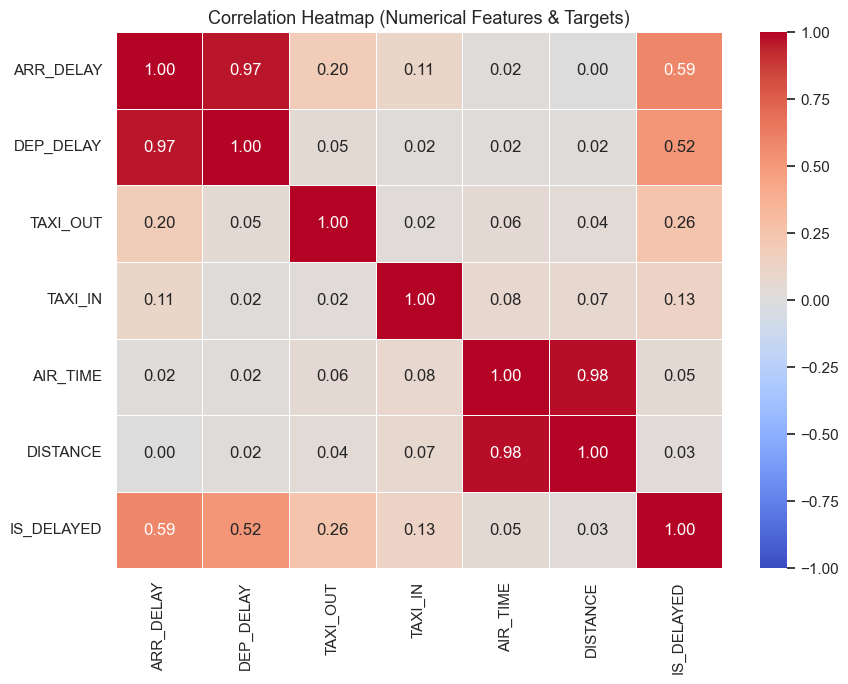

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define list of numerical features including the target variables
corr_features = [
    'ARR_DELAY', 'DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 
    'AIR_TIME', 'DISTANCE', 'IS_DELAYED'
]

# 2. Compute the Pearson correlation matrix
corr_matrix = df_clean[corr_features].corr()

# 3. Plot the correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)
plt.title('Correlation Heatmap (Numerical Features & Targets)', fontsize=13)
plt.tight_layout()
plt.show()

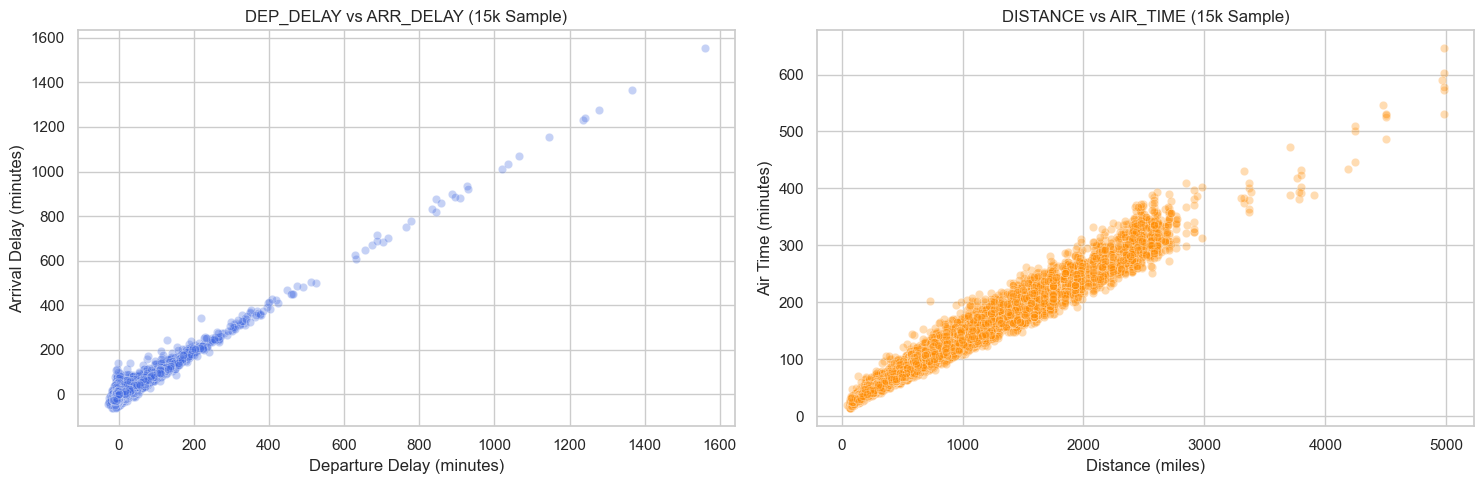

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take a random sample of 15,000 rows to ensure fast rendering without lag
sample_df = df_clean.sample(15000, random_state=42)

# Create 1x2 subplots for primary relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. DEP_DELAY vs ARR_DELAY (Direct Linear Relationship)
sns.scatterplot(
    data=sample_df, 
    x='DEP_DELAY', 
    y='ARR_DELAY', 
    alpha=0.3, 
    color='royalblue', 
    ax=axes[0]
)
axes[0].set_title('DEP_DELAY vs ARR_DELAY (15k Sample)')
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Arrival Delay (minutes)')

# 2. DISTANCE vs AIR_TIME (Collinearity Visualization)
sns.scatterplot(
    data=sample_df, 
    x='DISTANCE', 
    y='AIR_TIME', 
    alpha=0.3, 
    color='darkorange', 
    ax=axes[1]
)
axes[1].set_title('DISTANCE vs AIR_TIME (15k Sample)')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Air Time (minutes)')

plt.tight_layout()
plt.show()

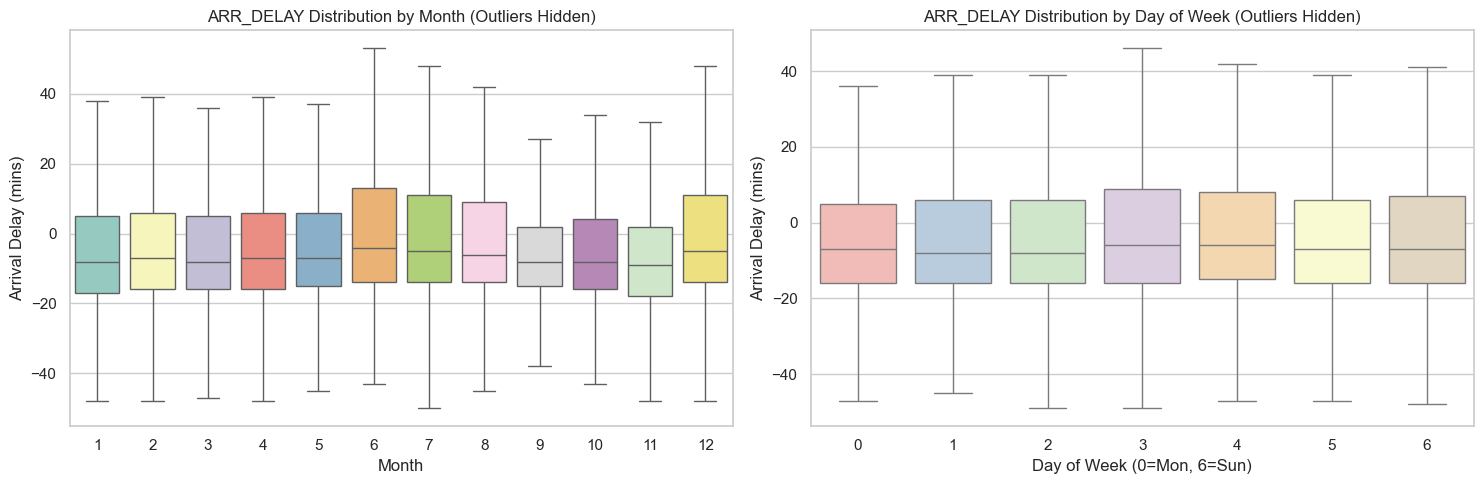

In [27]:
# Create subplots for temporal categories vs Arrival Delay
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Arrival Delay by Month
sns.boxplot(
    data=sample_df, 
    x='MONTH', 
    y='ARR_DELAY', 
    hue='MONTH',
    ax=axes[0], 
    palette='Set3', 
    showfliers=False,
    legend=False
)
axes[0].set_title('ARR_DELAY Distribution by Month (Outliers Hidden)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Arrival Delay (mins)')

# 2. Arrival Delay by Day of Week (0 = Monday, 6 = Sunday)
sns.boxplot(
    data=sample_df, 
    x='DAY_OF_WEEK', 
    y='ARR_DELAY', 
    hue='DAY_OF_WEEK',
    ax=axes[1], 
    palette='Pastel1', 
    showfliers=False,
    legend=False
)
axes[1].set_title('ARR_DELAY Distribution by Day of Week (Outliers Hidden)')
axes[1].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[1].set_ylabel('Arrival Delay (mins)')

plt.tight_layout()
plt.show()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_7096\3952174186.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ahmed\AppData\Local\Temp\ipykernel_7096\3952174186.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


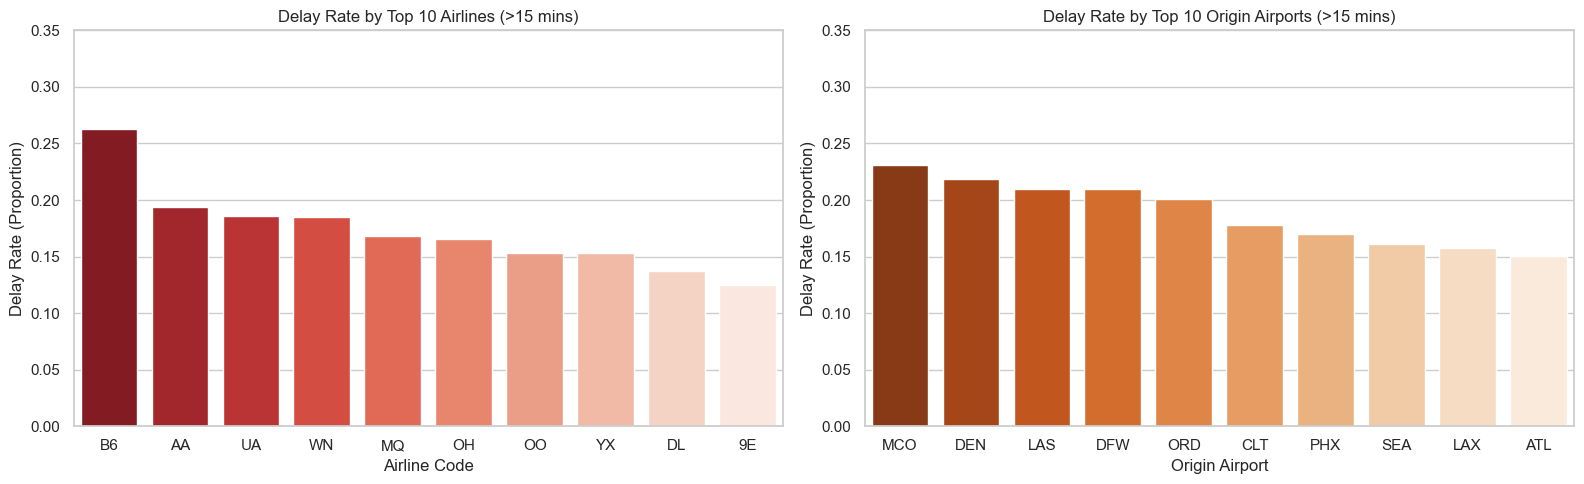

In [28]:
# Create subplots for delay rates across categories
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Delay Rate by Top 10 Airlines
top_10_airlines = df_clean['AIRLINE_CODE'].value_counts().head(10).index
airline_delay_rate = (
    df_clean[df_clean['AIRLINE_CODE'].isin(top_10_airlines)]
    .groupby('AIRLINE_CODE')['IS_DELAYED']
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(
    x=airline_delay_rate.index, 
    y=airline_delay_rate.values, 
    palette='Reds_r', 
    ax=axes[0]
)
axes[0].set_title('Delay Rate by Top 10 Airlines (>15 mins)')
axes[0].set_ylabel('Delay Rate (Proportion)')
axes[0].set_xlabel('Airline Code')
axes[0].set_ylim(0, 0.35)

# 2. Delay Rate by Top 10 Origin Airports
top_10_airports = df_clean['ORIGIN'].value_counts().head(10).index
airport_delay_rate = (
    df_clean[df_clean['ORIGIN'].isin(top_10_airports)]
    .groupby('ORIGIN')['IS_DELAYED']
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(
    x=airport_delay_rate.index, 
    y=airport_delay_rate.values, 
    palette='Oranges_r', 
    ax=axes[1]
)
axes[1].set_title('Delay Rate by Top 10 Origin Airports (>15 mins)')
axes[1].set_ylabel('Delay Rate (Proportion)')
axes[1].set_xlabel('Origin Airport')
axes[1].set_ylim(0, 0.35)

plt.tight_layout()
plt.show()

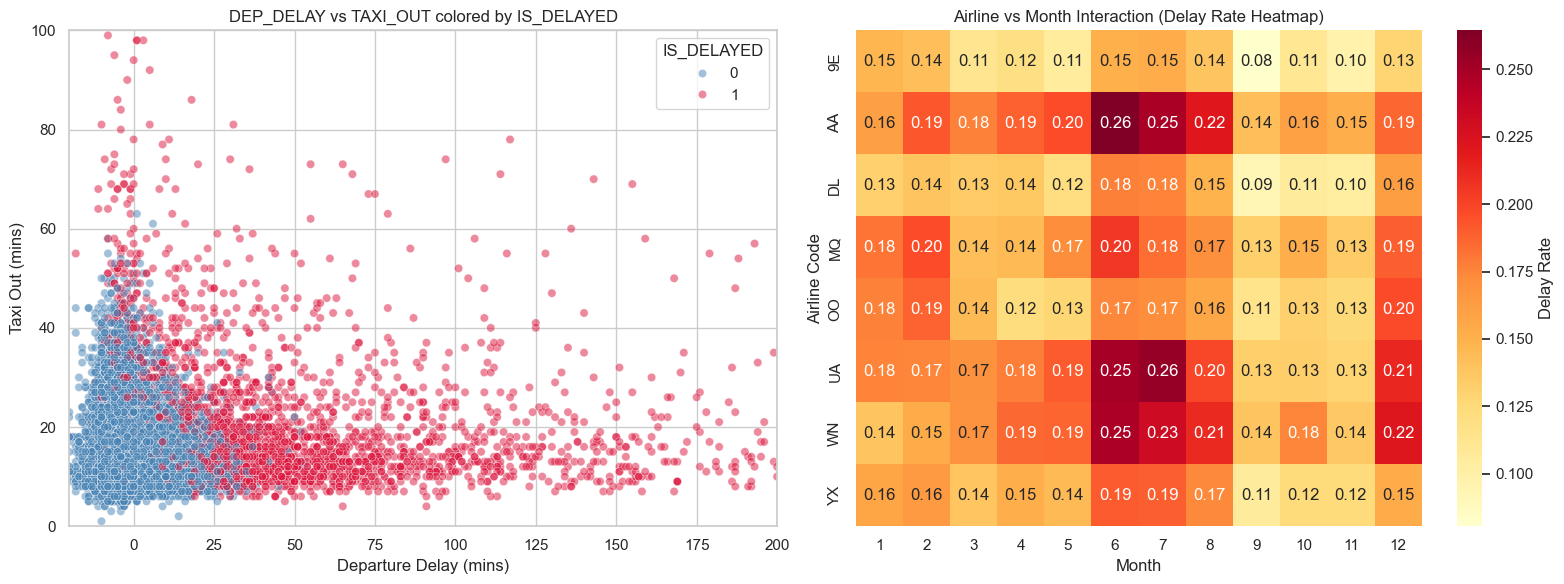

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter Plot with Hue (3 Variables: DEP_DELAY, TAXI_OUT, IS_DELAYED)
sns.scatterplot(
    data=sample_df,
    x='DEP_DELAY',
    y='TAXI_OUT',
    hue='IS_DELAYED',
    palette={0: 'steelblue', 1: 'crimson'},
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title('DEP_DELAY vs TAXI_OUT colored by IS_DELAYED')
axes[0].set_xlabel('Departure Delay (mins)')
axes[0].set_ylabel('Taxi Out (mins)')
axes[0].set_xlim(-20, 200)  # Zoom in for operational clarity
axes[0].set_ylim(0, 100)

# 2. Pivot Heatmap (3 Variables: Airline x Month -> Delay Rate)
top_airlines = df_clean['AIRLINE_CODE'].value_counts().head(8).index
airline_month_pivot = (
    df_clean[df_clean['AIRLINE_CODE'].isin(top_airlines)]
    .pivot_table(index='AIRLINE_CODE', columns='MONTH', values='IS_DELAYED', aggfunc='mean')
)

sns.heatmap(
    airline_month_pivot, 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd', 
    cbar_kws={'label': 'Delay Rate'},
    ax=axes[1]
)
axes[1].set_title('Airline vs Month Interaction (Delay Rate Heatmap)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Airline Code')

plt.tight_layout()
plt.show()

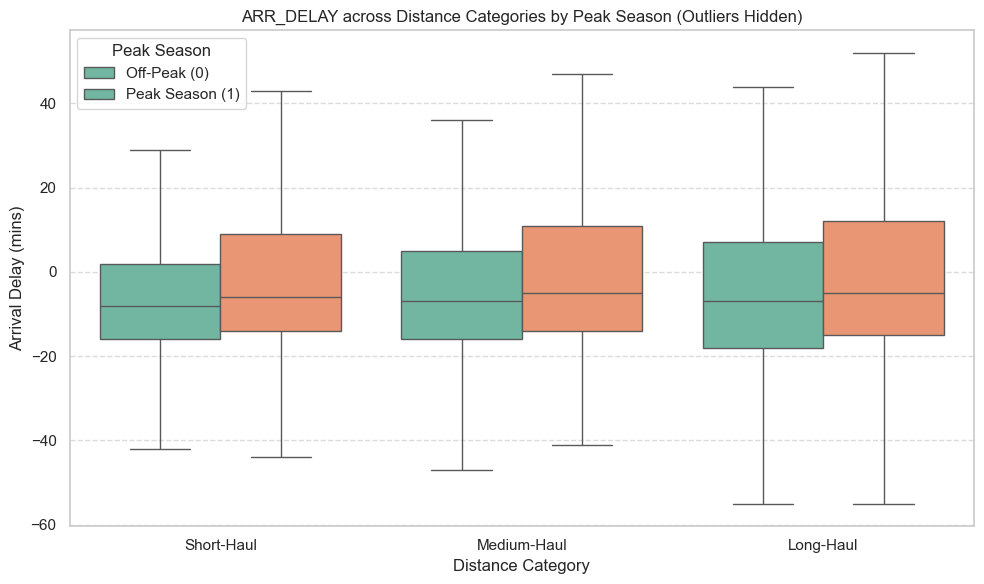

In [30]:
# 1. Create Distance Bins (Short, Medium, Long)
sample_df['DISTANCE_CAT'] = pd.qcut(
    sample_df['DISTANCE'], 
    q=3, 
    labels=['Short-Haul', 'Medium-Haul', 'Long-Haul']
)

# 2. Multivariate Boxplot: Distance Category vs Arrival Delay split by Peak Season
sample_df['IS_PEAK_SEASON'] = sample_df['MONTH'].isin([6, 7, 8, 12]).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=sample_df,
    x='DISTANCE_CAT',
    y='ARR_DELAY',
    hue='IS_PEAK_SEASON',
    palette='Set2',
    showfliers=False
)
plt.title('ARR_DELAY across Distance Categories by Peak Season (Outliers Hidden)')
plt.xlabel('Distance Category')
plt.ylabel('Arrival Delay (mins)')
plt.legend(title='Peak Season', labels=['Off-Peak (0)', 'Peak Season (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Feature Engineering & Preprocessing Pipeline

In [31]:
df_clean['FL_DATE'] = pd.to_datetime(df_clean['FL_DATE'])

df_clean['MONTH'] = df_clean['FL_DATE'].dt.month
df_clean['DAY_OF_WEEK'] = df_clean['FL_DATE'].dt.dayofweek

df_clean['IS_DELAYED'] = (
    df_clean['ARR_DELAY'] > 15
).astype(int)

print(df_clean['IS_DELAYED'].value_counts())
print(df_clean['IS_DELAYED'].value_counts(normalize=True))

IS_DELAYED
0    1598894
1     343875
Name: count, dtype: int64
IS_DELAYED
0    0.822997
1    0.177003
Name: proportion, dtype: float64


In [32]:
features = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE_CODE',
    'ORIGIN',
    'DEST',
    'DISTANCE',
    'TAXI_OUT',
    'TAXI_IN',
    'CRS_DEP_TIME',
    'CRS_ARR_TIME',
    'DEP_DELAY'
]

X = df_clean[features].copy()
y = df_clean['IS_DELAYED'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1942769, 11)
y shape: (1942769,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTrain delay ratio:")
print(y_train.mean())

print("\nTest delay ratio:")
print(y_test.mean())

X_train: (1554215, 11)
X_test : (388554, 11)

Train delay ratio:
0.1770025382588638

Test delay ratio:
0.17700242437344615


In [34]:
def engineer_features(data):
    data = data.copy()

    data['DEP_HOUR'] = (
        data['CRS_DEP_TIME'] // 100
    ).astype(int)

    data['ARR_HOUR'] = (
        data['CRS_ARR_TIME'] // 100
    ).astype(int)

    data['DEP_HOUR_SIN'] = np.sin(
        2 * np.pi * data['DEP_HOUR'] / 24
    )

    data['DEP_HOUR_COS'] = np.cos(
        2 * np.pi * data['DEP_HOUR'] / 24
    )

    data['ARR_HOUR_SIN'] = np.sin(
        2 * np.pi * data['ARR_HOUR'] / 24
    )

    data['ARR_HOUR_COS'] = np.cos(
        2 * np.pi * data['ARR_HOUR'] / 24
    )

    data.drop(
        columns=[
            'CRS_DEP_TIME',
            'CRS_ARR_TIME'
        ],
        inplace=True
    )

    return data

In [35]:
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (1554215, 15)
Test shape : (388554, 15)


In [36]:
global_mean = y_train.mean()
smoothing = 20

origin_stats = pd.DataFrame({
    'ORIGIN': X_train['ORIGIN'].values,
    'TARGET': y_train.values
}).groupby('ORIGIN')['TARGET'].agg([
    'count',
    'mean'
])

origin_encoding = (
    (
        origin_stats['count'] *
        origin_stats['mean']
    ) +
    (
        smoothing *
        global_mean
    )
) / (
    origin_stats['count'] +
    smoothing
)

X_train['ORIGIN_TE'] = (
    X_train['ORIGIN']
    .map(origin_encoding)
    .fillna(global_mean)
)

X_test['ORIGIN_TE'] = (
    X_test['ORIGIN']
    .map(origin_encoding)
    .fillna(global_mean)
)

In [37]:
dest_stats = pd.DataFrame({
    'DEST': X_train['DEST'].values,
    'TARGET': y_train.values
}).groupby('DEST')['TARGET'].agg([
    'count',
    'mean'
])

dest_encoding = (
    (
        dest_stats['count'] *
        dest_stats['mean']
    ) +
    (
        smoothing *
        global_mean
    )
) / (
    dest_stats['count'] +
    smoothing
)

X_train['DEST_TE'] = (
    X_train['DEST']
    .map(dest_encoding)
    .fillna(global_mean)
)

X_test['DEST_TE'] = (
    X_test['DEST']
    .map(dest_encoding)
    .fillna(global_mean)
)

In [38]:
X_train = pd.get_dummies(
    X_train,
    columns=['AIRLINE_CODE'],
    drop_first=True,
    dtype=np.int8
)

X_test = pd.get_dummies(
    X_test,
    columns=['AIRLINE_CODE'],
    drop_first=True,
    dtype=np.int8
)

In [39]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)


In [40]:
X_train.drop(
    columns=['ORIGIN', 'DEST'],
    inplace=True
)

X_test.drop(
    columns=['ORIGIN', 'DEST'],
    inplace=True
)

In [41]:
print(X_train.dtypes)

MONTH                int32
DAY_OF_WEEK          int32
DISTANCE           float64
TAXI_OUT           float64
TAXI_IN            float64
DEP_DELAY          float64
DEP_HOUR             int64
ARR_HOUR             int64
DEP_HOUR_SIN       float64
DEP_HOUR_COS       float64
ARR_HOUR_SIN       float64
ARR_HOUR_COS       float64
ORIGIN_TE          float64
DEST_TE            float64
AIRLINE_CODE_AA       int8
AIRLINE_CODE_AS       int8
AIRLINE_CODE_B6       int8
AIRLINE_CODE_DL       int8
AIRLINE_CODE_EV       int8
AIRLINE_CODE_F9       int8
AIRLINE_CODE_G4       int8
AIRLINE_CODE_HA       int8
AIRLINE_CODE_MQ       int8
AIRLINE_CODE_NK       int8
AIRLINE_CODE_OH       int8
AIRLINE_CODE_OO       int8
AIRLINE_CODE_QX       int8
AIRLINE_CODE_UA       int8
AIRLINE_CODE_WN       int8
AIRLINE_CODE_YV       int8
AIRLINE_CODE_YX       int8
dtype: object


In [42]:
cap_cols = [
    'DISTANCE',
    'TAXI_OUT',
    'TAXI_IN',
    'DEP_DELAY'
]

caps = X_train[cap_cols].quantile(0.99)

for col in cap_cols:

    X_train[col] = np.clip(
        X_train[col],
        a_min=None,
        a_max=caps[col]
    )

    X_test[col] = np.clip(
        X_test[col],
        a_min=None,
        a_max=caps[col]
    )

print("Capping thresholds:")
print(caps)

Capping thresholds:
DISTANCE     2588.0
TAXI_OUT       52.0
TAXI_IN        33.0
DEP_DELAY     191.0
Name: 0.99, dtype: float64


In [44]:
from sklearn.preprocessing import RobustScaler

scale_cols = [
    'DISTANCE',
    'TAXI_OUT',
    'TAXI_IN',
    'DEP_DELAY',
    'ORIGIN_TE',
    'DEST_TE'
]

scaler = RobustScaler()

X_train[scale_cols] = scaler.fit_transform(
    X_train[scale_cols]
)

X_test[scale_cols] = scaler.transform(
    X_test[scale_cols]
)

print("RobustScaler completed.")

RobustScaler completed.


In [45]:
print(
    "Train missing values:",
    X_train.isnull().sum().sum()
)

print(
    "Test missing values:",
    X_test.isnull().sum().sum()
)

Train missing values: 0
Test missing values: 0


In [46]:
print("Final X_train shape:", X_train.shape)
print("Final X_test shape :", X_test.shape)

print("Final y_train shape:", y_train.shape)
print("Final y_test shape :", y_test.shape)

Final X_train shape: (1554215, 31)
Final X_test shape : (388554, 31)
Final y_train shape: (1554215,)
Final y_test shape : (388554,)


In [47]:
print("Train class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

print("\nTrain class ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest class ratio:")
print(y_test.value_counts(normalize=True))

Train class distribution:
IS_DELAYED
0    1279115
1     275100
Name: count, dtype: int64

Test class distribution:
IS_DELAYED
0    319779
1     68775
Name: count, dtype: int64

Train class ratio:
IS_DELAYED
0    0.822997
1    0.177003
Name: proportion, dtype: float64

Test class ratio:
IS_DELAYED
0    0.822998
1    0.177002
Name: proportion, dtype: float64


In [48]:
print("Train:")
display(X_train.head())

print("\nTest:")
display(X_test.head())

Train:


,MONTH,DAY_OF_WEEK,DISTANCE,TAXI_OUT,TAXI_IN,DEP_DELAY,DEP_HOUR,ARR_HOUR,DEP_HOUR_SIN,DEP_HOUR_COS,...,AIRLINE_CODE_HA,AIRLINE_CODE_MQ,AIRLINE_CODE_NK,AIRLINE_CODE_OH,AIRLINE_CODE_OO,AIRLINE_CODE_QX,AIRLINE_CODE_UA,AIRLINE_CODE_WN,AIRLINE_CODE_YV,AIRLINE_CODE_YX
1959094,6,1,-0.136228,-0.500,-0.2,0.250000,6,6,1.000000e+00,6.123234e-17,...,0,0,0,0,0,0,0,1,0,0
1681336,2,0,2.896707,0.125,-0.2,-0.500000,18,21,-1.000000e+00,-1.836970e-16,...,0,0,0,0,0,0,1,0,0,0
1462064,1,2,-0.473054,-0.750,-0.4,-0.333333,12,14,1.224647e-16,-1.000000e+00,...,0,0,0,0,0,0,0,1,0,0
1474472,10,1,0.172156,1.500,-0.2,-0.416667,19,21,-9.659258e-01,2.588190e-01,...,0,0,0,0,1,0,0,0,0,0
742762,10,1,0.035928,-0.250,0.0,-0.416667,20,23,-8.660254e-01,5.000000e-01,...,0,0,0,0,1,0,0,0,0,0



Test:


,MONTH,DAY_OF_WEEK,DISTANCE,TAXI_OUT,TAXI_IN,DEP_DELAY,DEP_HOUR,ARR_HOUR,DEP_HOUR_SIN,DEP_HOUR_COS,...,AIRLINE_CODE_HA,AIRLINE_CODE_MQ,AIRLINE_CODE_NK,AIRLINE_CODE_OH,AIRLINE_CODE_OO,AIRLINE_CODE_QX,AIRLINE_CODE_UA,AIRLINE_CODE_WN,AIRLINE_CODE_YV,AIRLINE_CODE_YX
30872,6,3,-0.643713,0.125,-0.6,0.500000,13,14,-2.588190e-01,-0.965926,...,0,0,0,0,0,0,0,1,0,0
1897327,9,2,-0.019461,-0.625,-0.6,-0.500000,15,16,-7.071068e-01,-0.707107,...,0,0,0,0,0,0,0,0,0,0
1472945,8,0,-0.468563,0.750,0.2,-0.416667,14,16,-5.000000e-01,-0.866025,...,0,0,0,0,0,0,0,0,0,1
1330650,5,1,-0.467066,0.250,0.4,-0.416667,13,15,-2.588190e-01,-0.965926,...,0,0,0,0,0,0,0,0,0,0
1519876,2,4,-0.299401,0.250,-0.2,0.083333,12,14,1.224647e-16,-1.000000,...,0,0,0,0,0,0,0,0,0,0


Model & Evaluation

In [49]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [50]:
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log))
print("PR-AUC   :", average_precision_score(y_test, y_prob_log))

Accuracy : 0.9321123962177715
Precision: 0.7523240450882601
Recall   : 0.9190112686295893
F1 Score : 0.8273555514831008
ROC-AUC  : 0.9766267781476478
PR-AUC   : 0.935978907061582


[[298971  20808]
 [  5570  63205]]


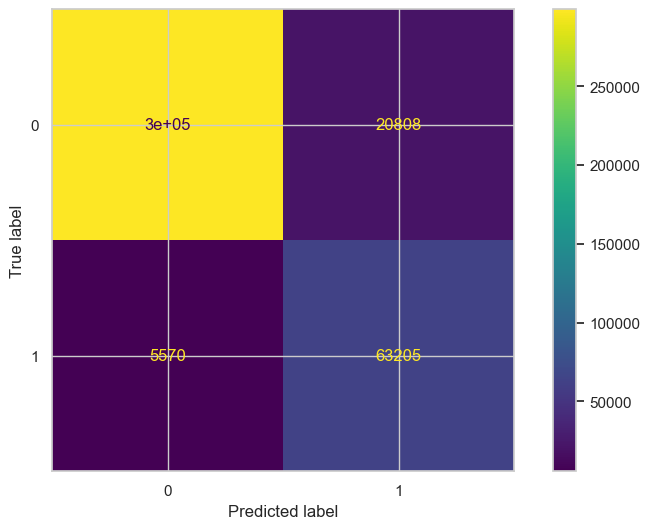

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.08
,max_iter,300
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,1.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [54]:
y_pred_hgb = hgb_model.predict(X_test)

y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

In [55]:
print("Accuracy :", accuracy_score(y_test, y_pred_hgb))
print("Precision:", precision_score(y_test, y_pred_hgb))
print("Recall   :", recall_score(y_test, y_pred_hgb))
print("F1 Score :", f1_score(y_test, y_pred_hgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_hgb))
print("PR-AUC   :", average_precision_score(y_test, y_prob_hgb))

Accuracy : 0.9565388594635494
Precision: 0.9135688324937831
Recall   : 0.8332969829153035
F1 Score : 0.8715885846380801
ROC-AUC  : 0.9808008179231116
PR-AUC   : 0.9467506235266406


In [56]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'HistGradientBoosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_hgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_hgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_hgb)
    ],
    'F1': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_hgb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_hgb)
    ],
    'PR_AUC': [
        average_precision_score(y_test, y_prob_log),
        average_precision_score(y_test, y_prob_hgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.932112,0.752324,0.919011,0.827356,0.976627,0.935979
1,HistGradientBoosting,0.956539,0.913569,0.833297,0.871589,0.980801,0.946751


In [57]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (
        y_prob_hgb >= threshold
    ).astype(int)

    f1_scores.append(
        f1_score(y_test, y_pred_threshold)
    )

best_threshold = thresholds[
    np.argmax(f1_scores)
]

best_f1 = max(f1_scores)

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.4099999999999998
Best F1: 0.872773968811578


In [58]:
y_pred_final = (
    y_prob_hgb >= best_threshold
).astype(int)

In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

Accuracy : 0.9556329364772979
Precision: 0.8861878784245549
Recall   : 0.8597600872410033
F1 Score : 0.872773968811578
